The given scrip plots the data over Grid map

In [68]:
import numpy as np
import pandas as pd
import datetime 
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from PIL import Image
from matplotlib.patches import Rectangle


In [66]:


def create_grid(width, depth):
    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180, 180
    
    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)
    # print(num_lon_cells)
    # Create an empty grid to store the IDs
    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    # Assign IDs to each grid cell
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            lat_start = min_lat + lat_idx * depth
            lat_end = lat_start + depth
            lon_start = min_lon + lon_idx * width
            lon_end = lon_start + width
            # grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}: (({lon_start},{lon_end}),({lat_start},{lat_end}))'
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}'
    
    return grid

# Example usage
grid = create_grid(20, 20)
print(grid)


[['G1' 'G2' 'G3' 'G4' 'G5' 'G6' 'G7' 'G8' 'G9' 'G10' 'G11' 'G12' 'G13'
  'G14' 'G15' 'G16' 'G17' 'G18']
 ['G19' 'G20' 'G21' 'G22' 'G23' 'G24' 'G25' 'G26' 'G27' 'G28' 'G29' 'G30'
  'G31' 'G32' 'G33' 'G34' 'G35' 'G36']
 ['G37' 'G38' 'G39' 'G40' 'G41' 'G42' 'G43' 'G44' 'G45' 'G46' 'G47' 'G48'
  'G49' 'G50' 'G51' 'G52' 'G53' 'G54']
 ['G55' 'G56' 'G57' 'G58' 'G59' 'G60' 'G61' 'G62' 'G63' 'G64' 'G65' 'G66'
  'G67' 'G68' 'G69' 'G70' 'G71' 'G72']
 ['G73' 'G74' 'G75' 'G76' 'G77' 'G78' 'G79' 'G80' 'G81' 'G82' 'G83' 'G84'
  'G85' 'G86' 'G87' 'G88' 'G89' 'G90']
 ['G91' 'G92' 'G93' 'G94' 'G95' 'G96' 'G97' 'G98' 'G99' 'G100' 'G101'
  'G102' 'G103' 'G104' 'G105' 'G106' 'G107' 'G108']
 ['G109' 'G110' 'G111' 'G112' 'G113' 'G114' 'G115' 'G116' 'G117' 'G118'
  'G119' 'G120' 'G121' 'G122' 'G123' 'G124' 'G125' 'G126']
 ['G127' 'G128' 'G129' 'G130' 'G131' 'G132' 'G133' 'G134' 'G135' 'G136'
  'G137' 'G138' 'G139' 'G140' 'G141' 'G142' 'G143' 'G144']
 ['G145' 'G146' 'G147' 'G148' 'G149' 'G150' 'G151' 'G152' 'G

Fn Creat_polygon will be checking the points based on x, y axis, means longitude, latitude. So strick around to this same order where ever you check the points or plot the points

In [5]:
def create_polygon(lat, lon, width):
    # Calculate the latitude and longitude for the four corners of the polygon
    lat_delta = width / 2
    lon_delta = width / 2
    latitudes = [lat - lat_delta, lat + lat_delta, lat + lat_delta, lat - lat_delta]
    longitudes = [lon - lon_delta, lon - lon_delta, lon + lon_delta, lon + lon_delta]

    # Create a polygon using the latitudes and longitudes
    polygon = Polygon(zip(longitudes, latitudes))

    return polygon

In [39]:
fn="1132_027640_20050108_120037_20050108_123753_full.pkl"
df = pd.read_pickle(f"D:\\ASCII-ICE\\{fn}")
orbit = fn.split('_')[1]

To plot the orbit over the Grid map

C:\Users\mbabu\AppData\Local\Temp\ipykernel_44016\1249894824.py:29: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


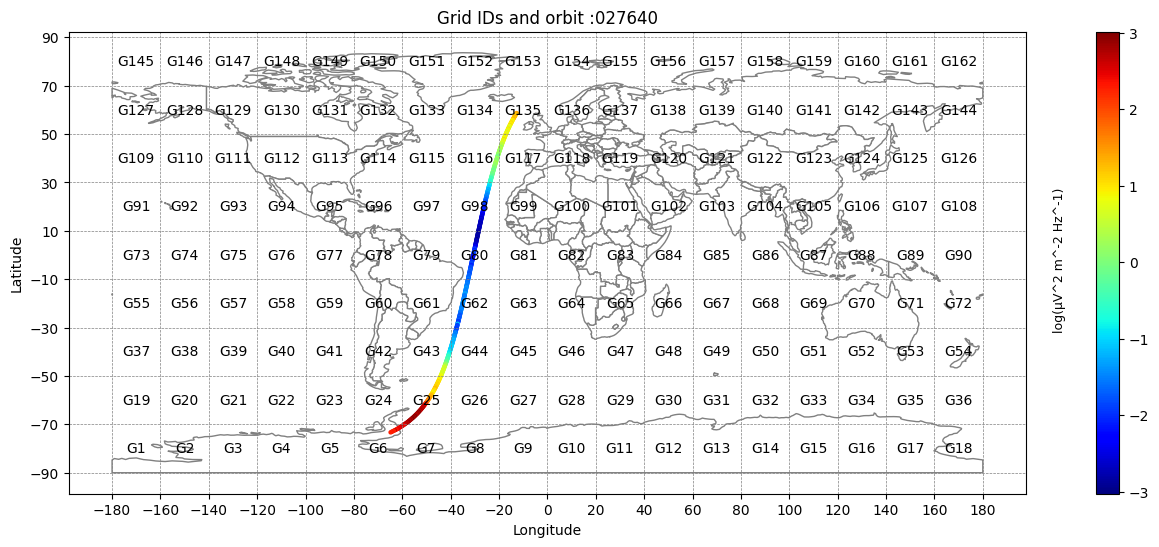

In [40]:



def plot_grid_with_ids(grid, width, depth,all_data,orbit):
   
    latitude = all_data['geoc_lat']
    longitude = all_data['geoc_long']
    spectrum_values = all_data['spectrum0'].values
    sp_01 = np.array([np.array(x) for x in spectrum_values])
    sp_01 = sp_01.astype(float)

    power_spectrum_at_freq = sp_01[:, freq_index]

    # Step 3: Create a GeoDataFrame with latitude and longitude coordinates
    all_data['geo_long'] = all_data['geoc_long'].apply(pd.to_numeric, errors='coerce')
    all_data['geom_long'] = all_data['geo_long'].apply(lambda x: x - 360 if x > 180 else x)
    gdf = gpd.GeoDataFrame(all_data, geometry=gpd.points_from_xy(all_data['geom_long'], all_data.geoc_lat))

    fig, ax = plt.subplots(figsize=(18, 6))
    cmap = 'jet'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, color='white', edgecolor='grey', zorder=1)
    scatter = gdf.plot(column=sp_01[:, freq_index], cmap=cmap, markersize=5, ax=ax, legend=True)
    # Plot latitude lines
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.5)

    # Plot longitude lines
    for lon in np.arange(0, 361, width):  # Adjusted range to match grid calculation
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.5)  # Adjusted longitude

    # Plot grid IDs
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width

            # Add grid ID text
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center')  # Adjusted longitude

    # Set x and y label frequency
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))
    fig.text(0.76, 0.5, 'log(μV^2 m^-2 Hz^-1)', va='center', rotation='vertical', fontsize=9)
    # Set title
    ax.set_title(f'Grid IDs and orbit :{orbit}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Show plot
    plt.show()



# Plot grid with IDs on world map
plot_grid_with_ids(grid, 20, 20, df, orbit)


To plot the orbit and mark a location with buffer 

float64


C:\Users\mbabu\AppData\Local\Temp\ipykernel_44016\44915343.py:23: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


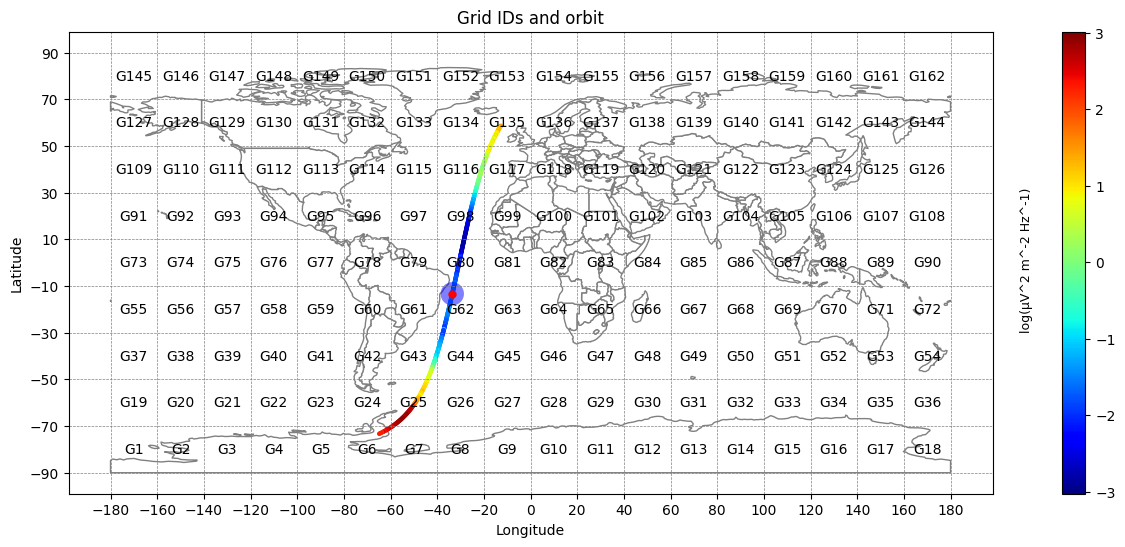

In [37]:


def plot_grid_with_ids(grid, width, depth, all_data):
    latitude = all_data['geoc_lat'].values
    longitude = all_data['geoc_long'].values
    print(longitude.dtype)
    spectrum_values = all_data['spectrum0'].values
    sp_01 = np.array([np.array(x) for x in spectrum_values])
    sp_01 = sp_01.astype(float)

    freq_list = np.linspace(19, 20000,)
    freq_of_interest = 19800
    freq_diff = np.abs(freq_list - freq_of_interest)
    freq_index = np.argmin(freq_diff)
    power_spectrum_at_freq = sp_01[:, freq_index]

    # Create a GeoDataFrame with latitude and longitude coordinates
    all_data['geo_long'] = all_data['geoc_long'].apply(pd.to_numeric, errors='coerce')
    all_data['geoc_long'] = all_data['geo_long'].apply(lambda x: x - 360 if x > 180 else x)
    gdf = gpd.GeoDataFrame(all_data, geometry=gpd.points_from_xy(all_data['geoc_long'], all_data.geoc_lat))

    # Plot all orbits on a single world map using Geopandas and Matplotlib
    fig, ax = plt.subplots(figsize=(18, 6))
    cmap = 'jet'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, color='white', edgecolor='grey', zorder=1)
    scatter = gdf.plot(column=sp_01[:, freq_index], cmap=cmap, markersize=5, ax=ax, legend=True)

    # Plot latitude lines
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.5)

    # Plot longitude lines
    for lon in np.arange(0, 361, width):  # Adjusted range to match grid calculation
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.5)  # Adjusted longitude

    # Plot grid IDs
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width

            # Add grid ID text
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center')  # Adjusted longitude

    # Plot the point at latitude -4.6217 and longitude -17.867
    ax.plot(-33.5347, -13.3184, marker='o', color='red', markersize=5)

    # Create a polygon with width 10 degrees centered at the point (-17.867, -4.6217)
    center_point = Point(-33.5347, -13.3184)
    buffer_polygon = center_point.buffer(5)

    # Plot the polygon
    patch = gpd.GeoSeries([buffer_polygon]).plot(ax=ax, color='blue', alpha=0.5)

    # Set x and y label frequency
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))
    fig.text(0.76, 0.5, 'log(μV^2 m^-2 Hz^-1)', va='center', rotation='vertical', fontsize=9)
    # Set title
    ax.set_title('Grid IDs and orbit')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Show plot
    plt.show()

# Create grid
grid = create_grid(20, 20)

# Plot grid with IDs on world map
plot_grid_with_ids(grid, 20, 20, df)


Collecting List of cordinates at evey 2 min interval of data

In [58]:

coordinate_list = list(zip(df['geoc_long'][::30], df['geoc_lat'][::30]))


for i, (lon, lat) in enumerate(coordinate_list):
    lon = float(lon)
    # Correcting the longitude value if it's greater than 180
    lon = int(lon) - 360 if lon > 180 else lon
    # Update the tuple in the list with the corrected longitude
    coordinate_list[i] = (lon, lat)


Plot the orbit with the location of satellite where the data has been calculated with its area of consideration 

C:\Users\mbabu\AppData\Local\Temp\ipykernel_44016\1830109748.py:22: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


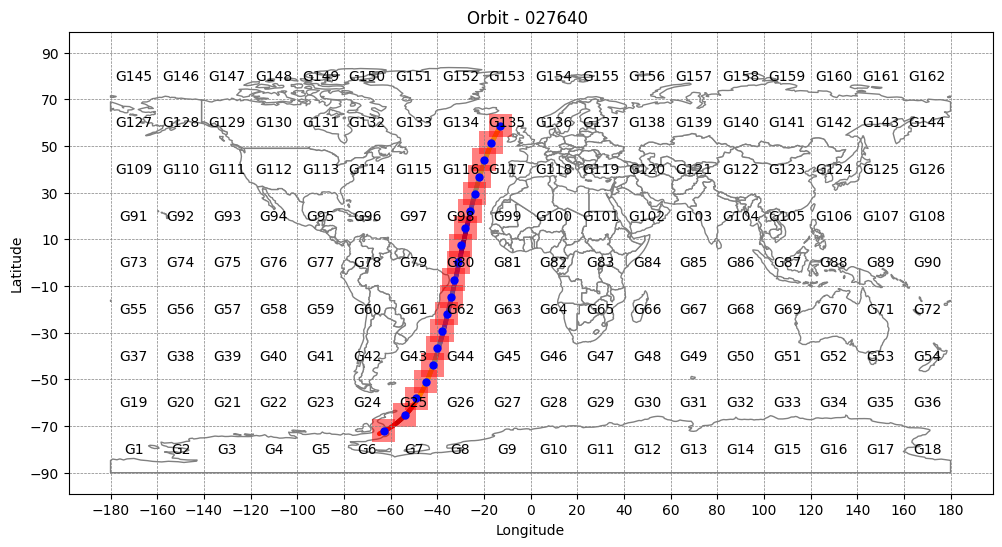

In [70]:


def plot_grid_with_ids_and_coordinates(grid, width, depth, all_data, coordinates_list,orbit):
    latitude = all_data['geoc_lat']
    longitude = all_data['geoc_long']
    spectrum_values = all_data['spectrum0'].values
    sp_01 = np.array([np.array(x) for x in spectrum_values])
    sp_01 = sp_01.astype(float)

    freq_list = np.linspace(19, 20000,)
    freq_of_interest = 19800
    freq_diff = np.abs(freq_list - freq_of_interest)
    freq_index = np.argmin(freq_diff)
    power_spectrum_at_freq = sp_01[:, freq_index]

    # Create a GeoDataFrame with latitude and longitude coordinates
    all_data['geo_long'] = all_data['geoc_long'].apply(pd.to_numeric, errors='coerce')
    all_data['geom_long'] = all_data['geo_long'].apply(lambda x: x - 360 if x > 180 else x)
    gdf = gpd.GeoDataFrame(all_data, geometry=gpd.points_from_xy(all_data['geom_long'], all_data.geoc_lat))

    # Plot all orbits on a single world map using Geopandas and Matplotlib
    fig, ax = plt.subplots(figsize=(24, 6))
    cmap = 'jet'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, color='white', edgecolor='grey', zorder=1)
    scatter = gdf.plot(column=sp_01[:, freq_index], cmap=cmap, markersize=5, ax=ax)

    # Plot latitude lines
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.5)

    # Plot longitude lines
    for lon in np.arange(0, 361, width):  # Adjusted range to match grid calculation
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.5)  # Adjusted longitude

    # Plot grid IDs
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width

            # Add grid ID text
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center')  # Adjusted longitude

    # Plot the coordinates from the list
    for coord in coordinates_list:


        ax.plot(float(coord[0]), float(coord[1]), marker='o', color='blue', markersize=5)

    for coord in coordinates_list:
        center_point = (float(coord[1]), float(coord[0]))
        half_width = 5
        square_polygon = Polygon([(center_point[1] - half_width, center_point[0] - half_width),
                                (center_point[1] + half_width, center_point[0] - half_width),
                                (center_point[1] + half_width, center_point[0] + half_width),
                                (center_point[1] - half_width, center_point[0] + half_width)])

    # Plot the polygon
        patch = gpd.GeoSeries([square_polygon]).plot(ax=ax, color='red', alpha=0.5)

    # Set x and y label frequency
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))

    # Set title
    ax.set_title(f'Orbit - {orbit} ')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.savefig('high_dpi_plot.png', dpi=300, bbox_inches='tight')
    # Show plot
    plt.show()
    # plt.savefig('high_dpi_plot.png', dpi=300, bbox_inches='tight')


# Plot grid with IDs on world map along with additional coordinates
plot_grid_with_ids_and_coordinates(grid, 20, 20, df, coordinate_list,orbit)


Marling the Grids of choice 

C:\Users\mbabu\AppData\Local\Temp\ipykernel_44016\1382205132.py:4: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


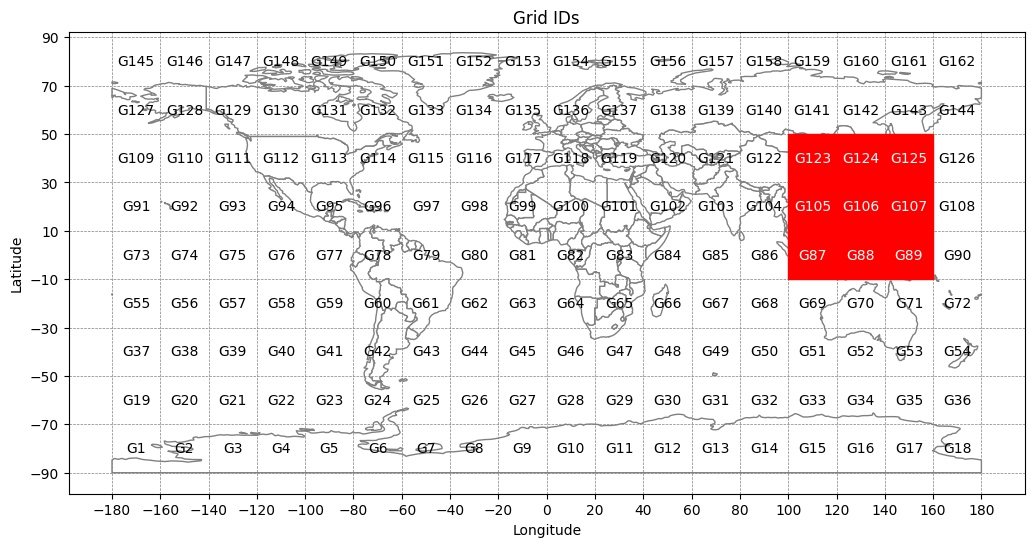

In [72]:


# Function to plot grid with specified cells in red
def plot_grid_with_red(grid, width, depth, target_grids):
    fig, ax = plt.subplots(figsize=(18, 6))
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, color='white', edgecolor='grey', zorder=1)
    
    # Plot latitude lines
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.5)
    
    # Plot longitude lines
    for lon in np.arange(-180, 181, width):
        ax.axvline(x=lon, color='gray', linestyle='--', linewidth=0.5)
    
    # Plot grid cells
    for lat_idx in range(grid.shape[0]):
        for lon_idx in range(grid.shape[1]):
            lat_start = -90 + lat_idx * depth
            lon_start = -180 + lon_idx * width
            cell_id = grid[lat_idx, lon_idx]

            if cell_id in target_grids:
                rect = Rectangle((lon_start, lat_start), width, depth, edgecolor='red', facecolor='red', zorder=2)
                ax.add_patch(rect)
                ax.text(lon_start + width / 2, lat_start + depth / 2, cell_id,
                        ha='center', va='center', color='white', zorder=3)
            else:
                ax.text(lon_start + width / 2, lat_start + depth / 2, cell_id,
                        ha='center', va='center', color='black', zorder=3)
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))
    ax.set_title('Grid IDs')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.show()

# Example usage
grid = create_grid(20, 20)
plot_grid_with_red(grid, 20, 20, ['G123','G124','G125','G105','G106','G107','G87','G88','G89'])  # Pass a list of target grid cells
